### ANALISIS DE DATASET + FILTRACION DE DATASET

In [ ]:
pip install pandas matplotlib seaborn

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import Counter

plt.style.use('ggplot')  # O 'classic', según prefieras
# Leer el archivo CSV
try:
    file_path = "dataset_elpino.csv"
    df = pd.read_csv(file_path, sep=';', na_values=["NA", "NULL", "-"])
    print(f"Dataset cargado desde: {file_path}")
except FileNotFoundError:
    try:
        file_path = "../dataset_elpino.csv"
        df = pd.read_csv(file_path, sep=';', na_values=["NA", "NULL", "-"])
        print(f"Dataset cargado desde: {file_path}")
    except FileNotFoundError:
        print("Error: No se encontró el archivo dataset_elpino.csv")
        print("Por favor, asegúrate de que el archivo existe en la ruta correcta")
        # Si estás ejecutando esto en un script, es mejor salir
        # Si estás en Jupyter, puedes comentar la siguiente línea
        # exit()

# Mostrar primeras y últimas 3 filas
print("Primeras 3 filas:")
print(df.head(3))

print("\nÚltimas 3 filas:")
print(df.tail(3))

# Dimensiones del dataset
rows, columns = df.shape
print(f"\nNúmero de filas: {rows} y columnas: {columns} en el dataset.")

# Estadísticas básicas
print("\nResumen del dataset:")
print(df.describe(include='all'))

# Análisis de valores faltantes
print("\nAnálisis de valores faltantes:")
missing_counts = df.isna().sum()
total_missing = missing_counts.sum()
missing_percentage = (total_missing / (rows * columns)) * 100
print(f"Total de valores vacíos en todas las columnas: {total_missing}")
print(f"Porcentaje de valores faltantes: {missing_percentage:.2f}%")

# Graficar valores faltantes
plt.figure(figsize=(15, 14))
missing_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Valores Vacíos por Columna")
plt.xlabel("Columnas")
plt.ylabel("Cantidad de Valores Faltantes")
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("valores_faltantes.png")
plt.close()

print("\n## Conclusión de esta parte: Este archivo tiene {rows} filas y {columns} columnas, y en todas estas columnas se pueden ver {total_missing} valores vacíos. Pero no es un gran problema porque algunas de las celdas son de pacientes posiblemente recuperados.")

# Análisis de género
print("\nDatos de género:")
column_sex = df["Sexo (Desc)"]
unique_genders = column_sex.unique()
print("\n".join([str(g) for g in unique_genders]))

# Conteo de géneros y gráfico circular
gender_counts = column_sex.value_counts()
total = gender_counts.sum()
percentages = (gender_counts / total * 100).round(2)

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['skyblue', 'lightcoral'])
plt.title("Distribución por Género")
plt.tight_layout()
plt.savefig("distribucion_genero.png")
plt.close()

# Análisis de GRD
print("\nAnálisis de GRD:")
column_grd = df["GRD"]
grd_unique = column_grd.unique()
print(f"Esta lista tiene {len(grd_unique)} GRD, y todos ellos son:")
for i, grd in enumerate(grd_unique):
    print(f"    {i+1}) {grd}")

# Frecuencia de GRD
grd_counts = Counter(df["GRD"])
top_20_grd = sorted(grd_counts.items(), key=lambda x: -x[1])[:20]
bottom_20_grd = sorted(grd_counts.items(), key=lambda x: x[1])[:20]

print("\nTop 20 GRD más frecuentes:")
for i, (grd, count) in enumerate(top_20_grd, 1):
    print(f"    {i}) {grd} -> {count} veces")

# Análisis de partos (ajustar según tus datos reales)
partos = 813 + 639 + 538 + 389 + 325 + 187 + 140
porcentaje_partos = round(partos / rows * 100, 2)
print(f"\nEste es un aproximado de {porcentaje_partos}% de los datos de parto en el dataset.")

print("\nTop 20 GRD menos frecuentes:")
for i, (grd, count) in enumerate(bottom_20_grd, 1):
    print(f"    {i}) {grd} -> {count} veces")

print("\nGRD con menos de 3 ocurrencias:")
filtered_grd = [(grd, count) for grd, count in grd_counts.items() if count <= 3]
total_count_grd_less_3 = sum(count for grd, count in filtered_grd)
print(f"Esto es un total de: {len(filtered_grd)}, y todos los casos son {total_count_grd_less_3}:")
for i, (grd, count) in enumerate(filtered_grd, 1):
    print(f"    {i}) {grd} -> {count} veces")

grd_menor_igual_3_porcentaje = round(total_count_grd_less_3 / rows * 100, 2)
print(f"Cantidad de enfermedades no comunes en el dataset: {total_count_grd_less_3}, y esto es un {grd_menor_igual_3_porcentaje}% del dataset")

# Crear el archivo filtered_data_elpino.csv
print("\nCreando archivo filtered_data_elpino.csv...")

# Filtrar filas con GRD que tienen más de 3 ocurrencias
frequent_grds = [grd for grd, count in grd_counts.items() if count > 3]
df_filtered = df[df["GRD"].isin(frequent_grds)]

# Guardar el dataset filtrado
filtered_file_path = "filtered_data_elpino.csv"
df_filtered.to_csv(filtered_file_path, sep=';', index=False)
print(f"Dataset filtrado guardado en: {filtered_file_path}")
print(f"Filas originales: {rows}, Filas después del filtrado: {len(df_filtered)}")
print(f"Se eliminaron {rows - len(df_filtered)} filas con GRD poco frecuentes.")

# Mostrar un resumen del flujo de procesamiento
print("\n## Flujo de procesamiento:")
print("1. dataset_elpino.csv → Filtrado inicial → filtered_data_elpino.csv")
print("2. filtered_data_elpino.csv → Limpieza y codificación → fullCell.csv")
print("3. fullCell.csv → Extracción de códigos → onlyCode.csv")
print("4. onlyCode.csv → Procesamiento GRD → withoutLastNumberGRD.csv")
print("5. withoutLastNumberGRD.csv → Label Encoding → label_encoding.csv")

Dataset cargado desde: dataset_elpino.csv
Primeras 3 filas:
                         Diag 01 Principal (cod+des)  \
0            A41.8 - Otras septicemias especificadas   
1               U07.1 - COVID-19, virus identificado   
2  K56.5 - Adherencias [bridas] intestinales con ...   

                     Diag 02 Secundario (cod+des)  \
0  B37.6 - Endocarditis debida a candida (I39.8*)   
1           J12.8 - Neumonía debida a otros virus   
2                           R57.2 - Shock séptico   

                        Diag 03 Secundario (cod+des)  \
0  I39.8 - Endocarditis, válvula no especificada,...   
1                                     R06.0 - Disnea   
2                        R57.1 - Choque hipovolémico   

                        Diag 04 Secundario (cod+des)  \
0            N10 - Nefritis tubulointersticial aguda   
1                                          R05 - Tos   
2  J80 - Síndrome de dificultad respiratoria del ...   

                        Diag 05 Secundario (cod+des)

First 3 rows:


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...



Dataset dimensions: 14561 rows, 68 columns

Busqueda de la edad max y minima:
El índice del valor máximo de edad es: 2588
121
La edad maxima es 121 y la menor es 0

Separacion por edades:
Infante => 13.74%
Niños => 1.29%
Adolecente => 2.95%
Joven Adulto => 22.24%
Adulto => 35.27%
Adulto Mayor => 24.52%


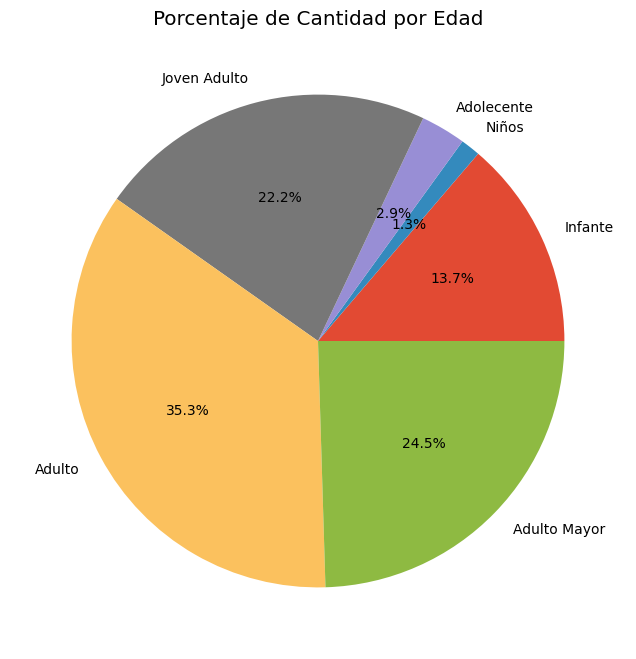


GRD mas comunes por segmento de edades

=== Infante ===
1. 158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR: 389 casos
2. 044163 - MH NEUMONÍA SIMPLE Y TOS FERINA W/MCC: 137 casos
3. 044183 - MH BRONQUIOLITIS Y ASMA W/MCC: 133 casos
4. 044213 - MH OTROS SIGNOS, SÍNTOMAS Y DIAGNÓSTICOS DE APARATO RESPIRATORIO W/MCC: 113 casos
5. 014241 - MH TRAUMATISMO CEFÁLICO: 83 casos

=== Niños ===
1. 014241 - MH TRAUMATISMO CEFÁLICO: 23 casos
2. 094131 - MH TRAUMATISMO DE PIEL, TEJIDO SUBCUTÁNEO Y MAMA: 21 casos
3. 064171 - MH DOLOR ABDOMINAL Y OTRAS GASTROENTERITIS: 12 casos
4. 014231 - MH MIGRAÑA Y OTRAS CEFALEAS: 11 casos
5. 044183 - MH BRONQUIOLITIS Y ASMA W/MCC: 8 casos

=== Adolecente ===
1. 061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE: 35 casos
2. 146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO: 31 casos
3. 214121 - MH ENVENENAMIENTO Y EFECTO TÓXICO DE DROGAS: 27 casos
4. 146131 - PH PARTO VAGINAL: 22 casos
5. 146101 - PH CESÁREA: 16 ca

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...



La edad maxima es 121 y la menor es 0

=== Infante ===
1. 158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR: 389 casos
2. 044163 - MH NEUMONÍA SIMPLE Y TOS FERINA W/MCC: 137 casos
3. 044183 - MH BRONQUIOLITIS Y ASMA W/MCC: 133 casos
4. 044213 - MH OTROS SIGNOS, SÍNTOMAS Y DIAGNÓSTICOS DE APARATO RESPIRATORIO W/MCC: 113 casos
5. 014241 - MH TRAUMATISMO CEFÁLICO: 83 casos

=== Niños ===
1. 014241 - MH TRAUMATISMO CEFÁLICO: 23 casos
2. 094131 - MH TRAUMATISMO DE PIEL, TEJIDO SUBCUTÁNEO Y MAMA: 21 casos
3. 064171 - MH DOLOR ABDOMINAL Y OTRAS GASTROENTERITIS: 12 casos
4. 014231 - MH MIGRAÑA Y OTRAS CEFALEAS: 11 casos
5. 044183 - MH BRONQUIOLITIS Y ASMA W/MCC: 8 casos

=== Adolecente ===
1. 061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE: 35 casos
2. 146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO: 31 casos
3. 214121 - MH ENVENENAMIENTO Y EFECTO TÓXICO DE DROGAS: 27 casos
4. 146131 - PH PARTO VAGINAL: 22 casos
5. 146101 - PH CESÁREA: 16 cas

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Read the CSV file
file_path = "dataset_elpino.csv"
data_el_pino = pd.read_csv(file_path, sep=';', na_values=["NA", "NULL", "-"])

# Display first 3 rows
print("First 3 rows:")
display(data_el_pino.head(3))

# Get dataset dimensions
rows, columns = data_el_pino.shape
print(f"\nDataset dimensions: {rows} rows, {columns} columns")

# Age analysis
print("\nBusqueda de la edad max y minima:")
age = data_el_pino["Edad en años"]
edad_maxima, edad_minima = age.max(), age.min()

indice_maximo = age.idxmax()
print(f"El índice del valor máximo de edad es: {indice_maximo}")
print(age[indice_maximo])

print(f"La edad maxima es {edad_maxima} y la menor es {edad_minima}")  # Note: 0 represents newborns

# Age segmentation
print("\nSeparacion por edades:")
infante = [edad for edad in age if edad <= 5 and edad >= 0]
child = [edad for edad in age if edad <= 12 and edad >= 6]
adolecente = [edad for edad in age if edad <= 18 and edad >= 13]
joven_adulto = [edad for edad in age if edad <= 30 and edad >= 19]
adulto = [edad for edad in age if edad <= 60 and edad >= 31]
adulto_mayor = [edad for edad in age if edad >= 61]

nombre_segmentacion = ["Infante", "Niños", "Adolecente", "Joven Adulto", "Adulto", "Adulto Mayor"]
cantidad_por_edad = [
    len(infante),
    len(child),
    len(adolecente),
    len(joven_adulto),
    len(adulto),
    len(adulto_mayor)
]

def calcular_porcentaje(x, total):
    return round(x/total * 100, 2)

porcentaje_cantidad_por_edad = [calcular_porcentaje(x, rows) for x in cantidad_por_edad]

for i in range(len(nombre_segmentacion)):
    print(f"{nombre_segmentacion[i]} => {porcentaje_cantidad_por_edad[i]}%")

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(porcentaje_cantidad_por_edad, labels=nombre_segmentacion, autopct='%1.1f%%')
plt.title("Porcentaje de Cantidad por Edad")
plt.show()

# GRD analysis by age segment
print("\nGRD mas comunes por segmento de edades")

segmentos = {
    "Infante": (0, 5),
    "Niños": (6, 12),
    "Adolecente": (13, 18),
    "Joven Adulto": (19, 30),
    "Adulto": (31, 60),
    "Adulto Mayor": (61, 150)  # Assuming reasonable maximum age
}

def top_grd_por_segmento(df, segmentos):
    resultados = {}

    for nombre, (min_edad, max_edad) in segmentos.items():
        subdf = df[(df["Edad en años"] >= min_edad) & (df["Edad en años"] <= max_edad)]

        if len(subdf) > 0:
            conteos = Counter(subdf["GRD"])
            top5 = sorted(conteos.items(), key=lambda x: x[1], reverse=True)[:5]
            resultados[nombre] = top5
        else:
            resultados[nombre] = "Sin casos registrados"

    return resultados

# Example usage
resultados = top_grd_por_segmento(data_el_pino, segmentos)

# Display results
for segmento, datos in resultados.items():
    print(f"\n=== {segmento} ===")
    if isinstance(datos, list):
        for i, (grd, conteo) in enumerate(datos, 1):
            print(f"{i}. {grd}: {conteo} casos")
    else:
        print(datos)

# Additional statistics
promedio_edad = round(age.mean())
mediana = age.median()
moda = age.mode()[0]  # Takes first mode if multiple
print("\nEstos son algunos analisis estadisticos adicionales:")
print(f"- Media: {promedio_edad}")
print(f"- Mediana: {mediana}")
print(f"- Moda: {moda}")

# Analysis with filtered data
print("\nAnalisis con datos filtrados")
second_file_path = "filtered_data_elpino.csv"
df2 = pd.read_csv(second_file_path, sep=';', na_values=["NA", "NULL", "-"])

print("\nFirst 3 rows of filtered data:")
display(df2.head(3))

rows2, columns2 = df2.shape

age2 = df2["Edad en años"]
edad_maxima2, edad_minima2 = age2.max(), age2.min()
print(f"\nLa edad maxima es {edad_maxima2} y la menor es {edad_minima2}")

# Age segmentation for filtered data
infante2 = [edad for edad in age2 if edad <= 5 and edad >= 0]
child2 = [edad for edad in age2 if edad <= 12 and edad >= 6]
adolecente2 = [edad for edad in age2 if edad <= 18 and edad >= 13]
joven_adulto2 = [edad for edad in age2 if edad <= 30 and edad >= 19]
adulto2 = [edad for edad in age2 if edad <= 60 and edad >= 31]
adulto_mayor2 = [edad for edad in age2 if edad >= 61]

# GRD analysis for filtered data
resultados2 = top_grd_por_segmento(df2, segmentos)

for segmento, datos in resultados2.items():
    print(f"\n=== {segmento} ===")
    if isinstance(datos, list):
        for i, (grd, conteo) in enumerate(datos, 1):
            print(f"{i}. {grd}: {conteo} casos")
    else:
        print(datos)

# Statistics for filtered data
promedio_edad2 = round(age2.mean())
mediana2 = age2.median()
moda2 = age2.mode()[0]
print("\nEstos son algunos analisis estadisticos adicionales:")
print(f"- Media: {promedio_edad2}")
print(f"- Mediana: {mediana2}")
print(f"- Moda: {moda2}")

In [65]:
import pandas as pd
import numpy as np
import re

# Read the CSV file
file_path = "filtered_data_elpino.csv"
filter_model1 = pd.read_csv(file_path, sep=';', na_values=["NA", "NULL", "-"])

# Display first 3 rows
print("First 3 rows:")
display(filter_model1.head(3))

# Delete row with index 2589 (Julia uses 1-based, Python uses 0-based)
filter_model1 = filter_model1.drop(2588)  # Python is 0-based, so 2588 corresponds to Julia's 2589

# Fill missing values in "Diag Secundario" columns
replacement_value = "?00-Posiblemente Recuperado"

# Find all columns containing "Diag" and "Secundario"
diag_columns = [col for col in filter_model1.columns
               if "Diag" in col and "Secundario" in col]

# Fill missing values
for col in diag_columns:
    filter_model1[col] = filter_model1[col].fillna(replacement_value)
    filter_model1[col] = np.where(filter_model1[col].isin(["", None]), replacement_value, filter_model1[col])

# Display first 3 rows to verify
print("\nAfter filling Diag Secundario columns:")
display(filter_model1.head(3))

# Fill missing values in "Proced Secundario" columns
replacement_value_proc = "0000.00 - Ya no necesita procedimiento"

# Find all columns containing "Proced" and "Secundario"
proc_columns = [col for col in filter_model1.columns
               if "Proced" in col and "Secundario" in col]

# Fill missing values
for col in proc_columns:
    filter_model1[col] = filter_model1[col].fillna(replacement_value_proc)
    filter_model1[col] = np.where(filter_model1[col].isin(["", None]), replacement_value_proc, filter_model1[col])

# Display first 3 rows to verify
print("\nAfter filling Proced Secundario columns:")
display(filter_model1.head(3))

# Function to count empty values
def is_empty(x):
    if pd.isna(x) or x is None or x == "":
        return True
    elif isinstance(x, (int, float)) and np.isnan(x):
        return True
    else:
        return False

def count_empty_as_dataframe(df):
    columns = df.columns
    empty_counts = [df[col].apply(is_empty).sum() for col in columns]
    return pd.DataFrame({'Columna': columns, 'Vacios': empty_counts})

empty_count = count_empty_as_dataframe(filter_model1)

# Save to new CSV file
path_file = "fullCell.csv"
filter_model1.to_csv(path_file, sep=';', index=False)

# Read the new file
data_model2 = pd.read_csv(path_file, sep=';')

# Convert gender to numerical values
data_model2["Sexo (Desc)"] = data_model2["Sexo (Desc)"].map({
    "Hombre": 1,
    "Mujer": 0
})

# Process diagnosis columns (1-35)
for i in range(1, 36):
    column_name = "Diag 01 Principal (cod+des)" if i == 1 else f"Diag {i:02d} Secundario (cod+des)"

    if column_name in data_model2.columns:
        data_model2[column_name] = data_model2[column_name].apply(
            lambda x: x.split("-")[0].strip() if pd.notna(x) and x != "" else np.nan
        )

# Process procedure columns (1-30)
for i in range(1, 31):
    column_name = "Proced 01 Principal (cod+des)" if i == 1 else f"Proced {i:02d} Secundario (cod+des)"

    if column_name in data_model2.columns:
        data_model2[column_name] = data_model2[column_name].apply(
            lambda x: x.split("-")[0].strip() if pd.notna(x) and x != "" else np.nan
        )

# Process GRD column
data_model2["GRD"] = data_model2["GRD"].apply(
    lambda x: x.split("-")[0].strip() if pd.notna(x) and x != "" else np.nan
)

# Save to new file
path_file2 = "onlyCode.csv"
data_model2.to_csv(path_file2, sep=';', index=False)

# Remove last character from GRD
data_model2["GRD"] = data_model2["GRD"].apply(
    lambda x: x[:-1] if pd.notna(x) and len(x) > 1 else np.nan
)

# Save final file
path_file3 = "withingLastNumberGRD.csv"
data_model2.to_csv(path_file3, sep=';', index=False)

# Display results
print("\nFinal DataFrame:")
display(data_model2.head(3))
print("\nGRD column after processing:")
display(data_model2["GRD"].head(5))

First 3 rows:


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...



After filling Diag Secundario columns:


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...



After filling Proced Secundario columns:


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...



Final DataFrame:


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8,B37.6,I39.8,N10,B96.1,L89.9,L08.9,B96.2,A41.5,J86.9,...,99.84,88.72,90.42,90.52,91.39,91.33,87.03,40,1,18410
1,U07.1,J12.8,R06.0,R05,R50.9,Z29.0,Z01.7,J96.00,J94.2,J92.9,...,91.62,90.43,91.39,90.52,91.32,96.59,90.99,53,1,04101
2,K56.5,R57.2,R57.1,J80,Y95,J15.0,U82.2,B95.6,B96.8,B37.1,...,99.84,91.73,90.53,99.26,89.39,89.66,89.65,65,1,04101



GRD column after processing:


,GRD
0,18410
1,04101
2,04101
3,04102
4,04102


In [66]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset
df = pd.read_csv('withingLastNumberGRD.csv', delimiter=';')

# Hacer una copia del DataFrame original
df_encoded = df.copy()

# Lista de columnas a procesar (excluyendo género que ya está en binario)
# Obtener todas las columnas excepto 'Sexo (Desc)'
columns_to_encode = [col for col in df.columns if col != 'Sexo (Desc)']

# Aplicar Label Encoding a las columnas de diagnóstico y procedimiento
print("Aplicando Label Encoding...")
label_encoders = {}
for column in columns_to_encode:
    if df[column].dtype == 'object':  # Solo aplicar a columnas categóricas
        le = LabelEncoder()
        # Manejar valores NaN reemplazándolos con una cadena especial
        df_encoded[column] = df_encoded[column].fillna('NA')
        df_encoded[column] = le.fit_transform(df_encoded[column].astype(str))
        label_encoders[column] = le

# Guardar el DataFrame con Label Encoding
print("Guardando versión con Label Encoding...")
df_encoded.to_csv('label_encoded_data.csv', index=False)

# Aplicar One-Hot Encoding
print("Aplicando One-Hot Encoding...")
# Crear un nuevo DataFrame para One-Hot Encoding
df_onehot = df.copy()

# Aplicar One-Hot Encoding a todas las columnas categóricas excepto género
for column in columns_to_encode:
    if df[column].dtype == 'object':  # Solo aplicar a columnas categóricas
        # Manejar valores NaN
        df_onehot[column] = df_onehot[column].fillna('NA')
        # Aplicar get_dummies
        dummies = pd.get_dummies(df_onehot[column], prefix=column)
        # Añadir las nuevas columnas al DataFrame
        df_onehot = pd.concat([df_onehot, dummies], axis=1)
        # Eliminar la columna original
        df_onehot.drop(column, axis=1, inplace=True)

# Guardar el DataFrame con One-Hot Encoding
print("Guardando versión con One-Hot Encoding...")
df_onehot.to_csv('onehot_encoded_data.csv', index=False)

print("\nEstadísticas del proceso:")
print(f"Número de columnas en el dataset original: {len(df.columns)}")
print(f"Número de columnas después de Label Encoding: {len(df_encoded.columns)}")
print(f"Número de columnas después de One-Hot Encoding: {len(df_onehot.columns)}")
print("\n¡Proceso completado! Los archivos han sido guardados en la carpeta dataModelCSV")


Aplicando Label Encoding...
Guardando versión con Label Encoding...
Aplicando One-Hot Encoding...
Guardando versión con One-Hot Encoding...

Estadísticas del proceso:
Número de columnas en el dataset original: 68
Número de columnas después de Label Encoding: 68
Número de columnas después de One-Hot Encoding: 15583

¡Proceso completado! Los archivos han sido guardados en la carpeta dataModelCSV


### MODELOS DE REDES NEURONALES

### ONE-HOT ENCODING

Dataset onehot_encoded_data.csv cargado exitosamente.
Dimensiones del dataset: (14278, 15583)
Primeras 5 filas:
   Proced 01 Principal (cod+des)  Proced 02 Secundario (cod+des)  \
0                          86.28                           34.91   
1                          31.10                           86.28   
2                          86.22                           54.59   
3                          54.19                           39.98   
4                          54.11                           45.90   

   Proced 03 Secundario (cod+des)  Proced 04 Secundario (cod+des)  \
0                           88.38                           87.41   
1                           96.72                           93.90   
2                           96.72                           31.10   
3                           86.28                           54.62   
4                           46.73                           46.20   

   Proced 05 Secundario (cod+des)  Proced 06 Secundario (cod+des

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 256)            │     3,989,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 158)            │        10,270 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,042,462 (15.42 MB)

 Trainable params: 4,041,566 (15.42 MB)

 Non-trainable params: 896 (3.50 KB)


Entrenando modelo...
Epoch 1/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.1361 - loss: 4.5185 - val_accuracy: 0.4604 - val_loss: 2.6791
Epoch 2/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step - accuracy: 0.4587 - loss: 2.5859 - val_accuracy: 0.5457 - val_loss: 2.1994
Epoch 3/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.6044 - loss: 1.8104 - val_accuracy: 0.6022 - val_loss: 1.8933
Epoch 4/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.7104 - loss: 1.3212 - val_accuracy: 0.6376 - val_loss: 1.7495
Epoch 5/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.7663 - loss: 1.0232 - val_accuracy: 0.6608 - val_loss: 1.6333
Epoch 6/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 40s 76ms/step - accuracy: 0.8085 - loss: 0.8064 - val_accuracy: 0.6490 - val_loss: 1.7077
Epoch 7/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 43s 81ms/step - accuracy: 0.8522 - loss: 0.6079 - val_accuracy: 0.6556 - val_loss: 1.6951
Epoch 8/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - accuracy: 0.

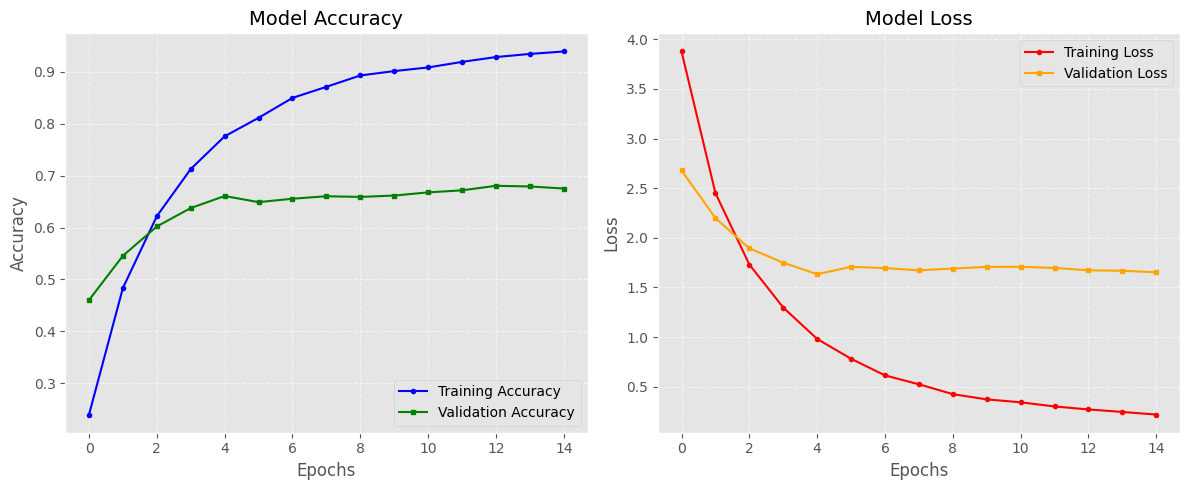


Evaluando modelo en conjunto de prueba...
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Resultados en el conjunto de prueba:
Accuracy: 0.6793
Precision: 0.6536
Recall: 0.6793


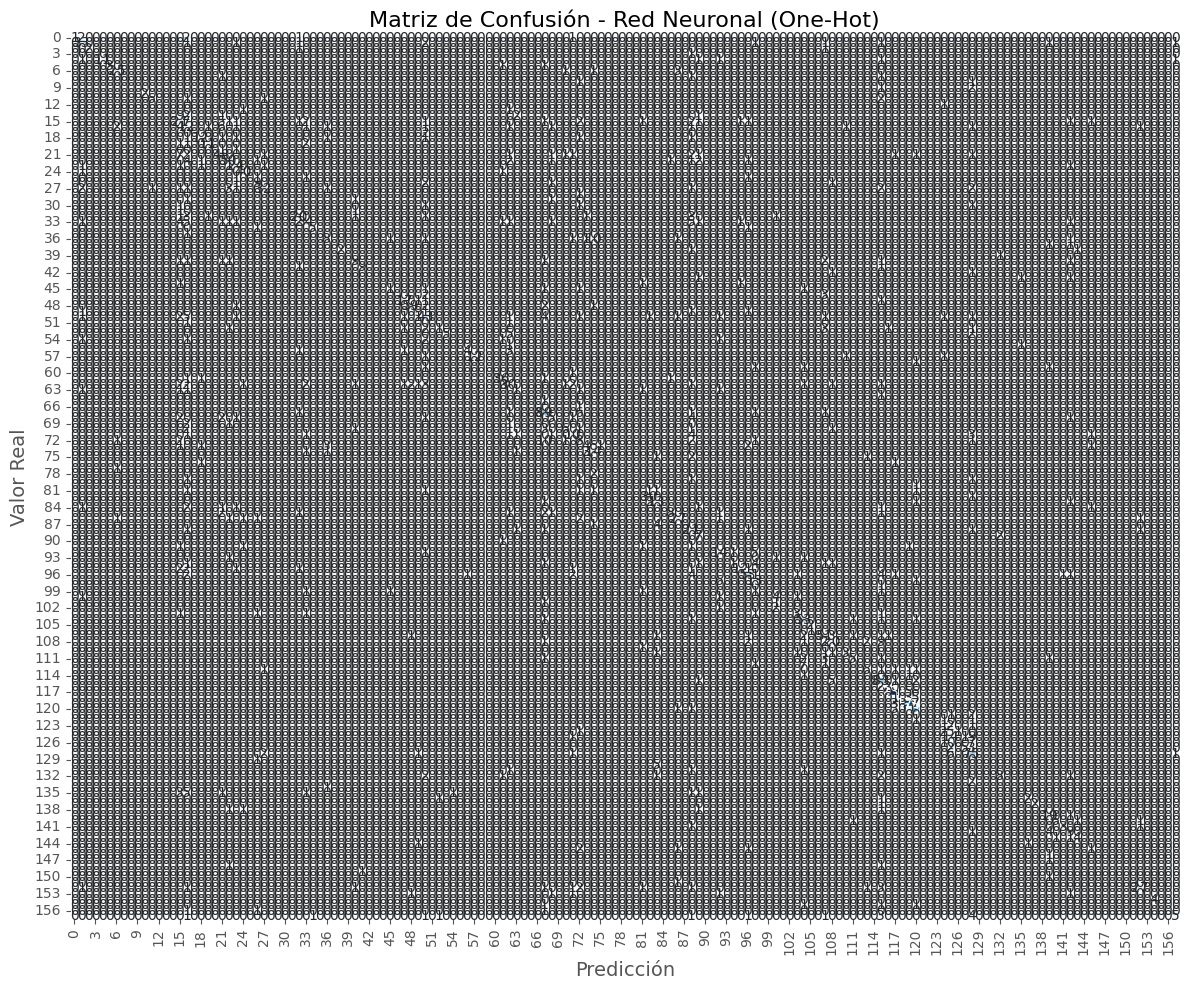

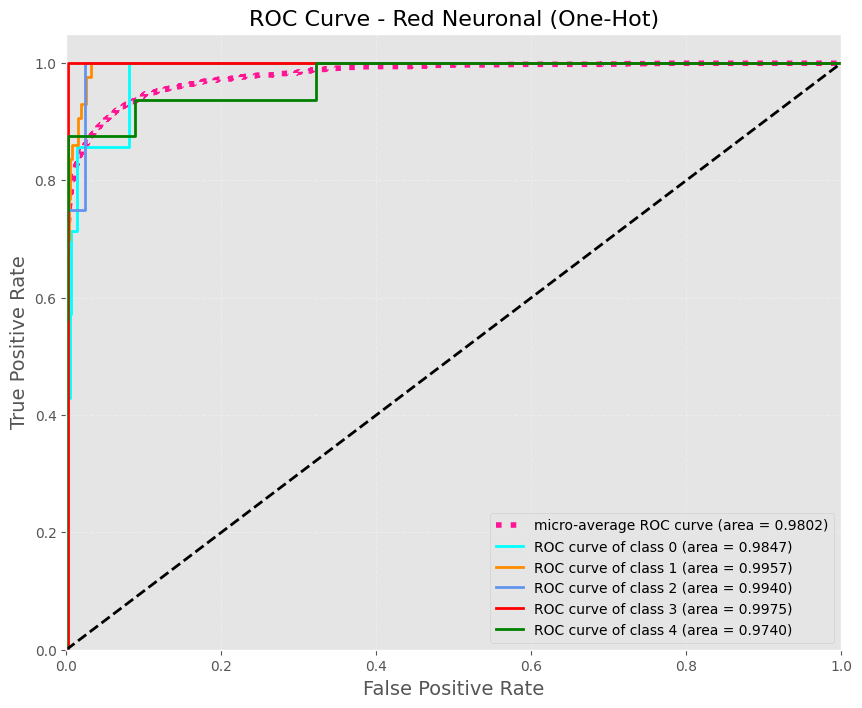


AUC micro-average: 0.9802

Realizando validación cruzada 5-fold...


Resultados de validación cruzada 5-fold:
Accuracy por fold: [0.6757111549377441, 0.642450749874115, 0.6409807205200195, 0.6611208319664001, 0.6589316725730896]
Accuracy media: 0.6558
Desviación estándar: 0.0129

Accuracy final de entrenamiento: 0.9393
Accuracy final de validación: 0.6753
Brecha entre entrenamiento y validación: 0.2640

Modelo guardado como 'neural_network_onehot_model.h5'

Realizando análisis de errores...

Errores más comunes (Verdadero -> Predicho):
Clase verdadera 120 predicha como 119: 11 veces
Clase verdadera 72 predicha como 67: 10 veces
Clase verdadera 36 predicha como 74: 10 veces
Clase verdadera 108 predicha como 115: 9 veces
Clase verdadera 125 predicha como 128: 9 veces
Clase verdadera 14 predicha como 15: 9 veces
Clase verdadera 21 predicha como 15: 7 veces
Clase verdadera 126 predicha como 128: 7 veces
Clase verdadera 15 predicha como 16: 7 veces
Clase verdadera 119 predicha como 120: 7 veces


In [61]:

# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

try:
    # Intentar cargar el archivo onehot_encoded_data.csv
    df = pd.read_csv("onehot_encoded_data.csv", sep=',')
    print("Dataset onehot_encoded_data.csv cargado exitosamente.")
except FileNotFoundError:
                print("Ningún archivo de datos encontrado. Verificar las rutas.")
                exit()

# Mostrar información básica del dataset
print(f"Dimensiones del dataset: {df.shape}")
print("Primeras 5 filas:")
print(df.head())

# Verificar si la columna 'GRD' existe en el dataset
if 'GRD' not in df.columns:
    print("Error: La columna 'GRD' no existe en el dataset.")
    # Buscar posibles columnas de target
    possible_targets = [col for col in df.columns if 'GRD' in col or 'target' in col.lower() or 'class' in col.lower()]
    if possible_targets:
        print(f"Posibles columnas target encontradas: {possible_targets}")
        target_col = possible_targets[0]
        print(f"Usando '{target_col}' como columna target.")
    else:
        print("No se encontraron posibles columnas target. Asumiendo que la última columna es el target.")
        target_col = df.columns[-1]
        print(f"Usando '{target_col}' como columna target.")
else:
    target_col = 'GRD'

# Separar features y target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Mostrar información sobre las clases
class_counts = y.value_counts()
print("\nDistribución de clases (GRD):")
print(class_counts)
n_classes = len(class_counts)
print(f"Número de clases: {n_classes}")

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar características (importante incluso con one-hot encoding)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# One-hot encode the target variable
lb = LabelBinarizer()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

# Verificar las dimensiones después del preprocesamiento
print(f"\nDimensiones después del preprocesamiento:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"y_train_encoded: {y_train_encoded.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_test_encoded: {y_test_encoded.shape}")

# Definir y compilar el modelo de red neuronal
print("\nCreando modelo de red neuronal...")
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

# Compilar el modelo
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
model.summary()

# Configurar early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Entrenar el modelo
print("\nEntrenando modelo...")
history = model.fit(
    X_train_scaled, y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Graficar curvas de aprendizaje (accuracy)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='blue', marker='o', markersize=3, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='green', marker='s', markersize=3, label='Validation Accuracy')
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Graficar curvas de aprendizaje (loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', marker='o', markersize=3, label='Training Loss')
plt.plot(history.history['val_loss'], color='orange', marker='s', markersize=3, label='Validation Loss')
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Evaluar el modelo
print("\nEvaluando modelo en conjunto de prueba...")
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)

# Calcular métricas
accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
recall = recall_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)

print("\nResultados en el conjunto de prueba:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Mostrar matriz de confusión
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Red Neuronal (One-Hot)', fontsize=16)
plt.xlabel('Predicción', fontsize=14)
plt.ylabel('Valor Real', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Calcular y visualizar ROC-AUC para multiclase
# Calcular ROC curve y ROC area para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_encoded[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular micro-average ROC curve y ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_encoded.ravel(), y_pred_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Graficar ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average ROC curve (area = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle=':', linewidth=4)

# Graficar ROC curve para algunas clases
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red', 'green']
for i, color in zip(range(min(5, n_classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve - Red Neuronal (One-Hot)', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Imprimir AUC promedio
print(f"\nAUC micro-average: {roc_auc['micro']:.4f}")

# Validación cruzada
print("\nRealizando validación cruzada 5-fold...")
# Para validación cruzada, necesitamos una función que entrene y evalúe el modelo
def build_and_evaluate_model(X_train, y_train):
    # Crear y compilar modelo
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Entrenar modelo con early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.3,
        callbacks=[early_stopping],
        verbose=0
    )

    return model

# Realizar validación cruzada manualmente
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in cv.split(X_train_scaled, y_train):
    # Obtener datos de entrenamiento y validación para esta iteración
    X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_cv_train = y_train_encoded[train_idx]
    y_cv_val = y_train_encoded[val_idx]

    # Entrenar modelo
    cv_model = build_and_evaluate_model(X_cv_train, y_cv_train)

    # Evaluar modelo
    _, accuracy = cv_model.evaluate(X_cv_val, y_cv_val, verbose=0)
    cv_scores.append(accuracy)

# Mostrar resultados de validación cruzada
print(f"Resultados de validación cruzada 5-fold:")
print(f"Accuracy por fold: {[score for score in cv_scores]}")
print(f"Accuracy media: {np.mean(cv_scores):.4f}")
print(f"Desviación estándar: {np.std(cv_scores):.4f}")

# Imprimir los valores finales de accuracy y loss
print(f"\nAccuracy final de entrenamiento: {history.history['accuracy'][-1]:.4f}")
print(f"Accuracy final de validación: {history.history['val_accuracy'][-1]:.4f}")
print(f"Brecha entre entrenamiento y validación: {history.history['accuracy'][-1] - history.history['val_accuracy'][-1]:.4f}")

# Guardar el modelo
model.save("neural_network_onehot_model.h5")
print("\nModelo guardado como 'neural_network_onehot_model.h5'")

# Análisis de errores
print("\nRealizando análisis de errores...")
error_indices = np.where(y_pred_classes != y_test_classes)[0]
error_counts = {}

for idx in error_indices:
    true_class = y_test_classes[idx]
    pred_class = y_pred_classes[idx]
    error_pair = (true_class, pred_class)

    if error_pair in error_counts:
        error_counts[error_pair] += 1
    else:
        error_counts[error_pair] = 1

# Mostrar los errores más comunes
print("\nErrores más comunes (Verdadero -> Predicho):")
sorted_errors = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)
for (true_class, pred_class), count in sorted_errors[:10]:
    print(f"Clase verdadera {true_class} predicha como {pred_class}: {count} veces")


### LABEL ENCODING

Dataset label_encoded_data.csv cargado exitosamente.
Dimensiones del dataset: (14278, 68)
Primeras 5 filas:
   Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
0                           24                            41   
1                         1364                           508   
2                          575                          1177   
3                          622                           670   
4                         1342                          1571   

   Diag 03 Secundario (cod+des)  Diag 04 Secundario (cod+des)  \
0                           373                           638   
1                          1016                           889   
2                          1051                           452   
3                           711                           120   
4                          1102                           964   

   Diag 05 Secundario (cod+des)  Diag 06 Secundario (cod+des)  \
0                            38                    

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_86 (Dense)                │ (None, 256)            │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 158)            │        10,270 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,622 (275.87 KB)

 Trainable params: 69,726 (272.37 KB)

 Non-trainable params: 896 (3.50 KB)


Entrenando modelo...
Epoch 1/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.1384 - loss: 4.4419 - val_accuracy: 0.3252 - val_loss: 3.0682
Epoch 2/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3122 - loss: 3.0428 - val_accuracy: 0.3751 - val_loss: 2.6313
Epoch 3/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3547 - loss: 2.7109 - val_accuracy: 0.3912 - val_loss: 2.4629
Epoch 4/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3642 - loss: 2.5875 - val_accuracy: 0.4197 - val_loss: 2.3393
Epoch 5/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3846 - loss: 2.4510 - val_accuracy: 0.4228 - val_loss: 2.2551
Epoch 6/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3932 - loss: 2.3770 - val_accuracy: 0.4433 - val_loss: 2.1859
Epoch 7/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3990 - loss: 2.3416 - val_accuracy: 0.4446 - val_loss: 2.1389
Epoch 8/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4177 - loss: 

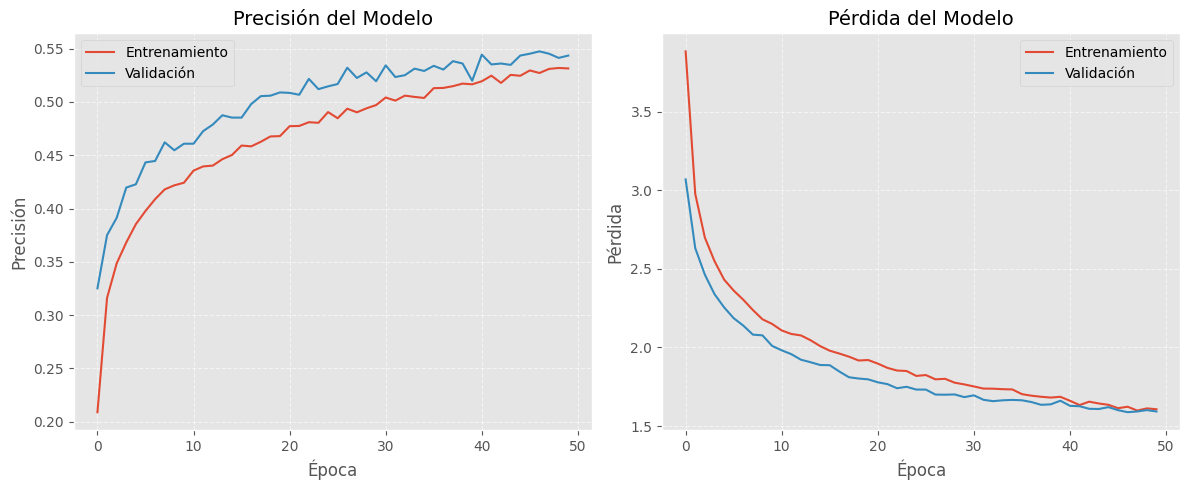


Evaluando modelo en el conjunto de prueba...
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Resultados en el conjunto de prueba:
Accuracy: 0.5564
Precision: 0.5123
Recall: 0.5564

Informe de clasificación detallado:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.38      0.65      0.48        43
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         1
           4       0.83      0.31      0.45        16
           5       0.00      0.00      0.00         5
           6       0.36      0.60      0.45        30
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         3
          10       0.50      1.00      0.67         2
          11       0.20      0.10      0.13        10
          12       0.00      0.00      0.00         1
          13       0.00      0.00 

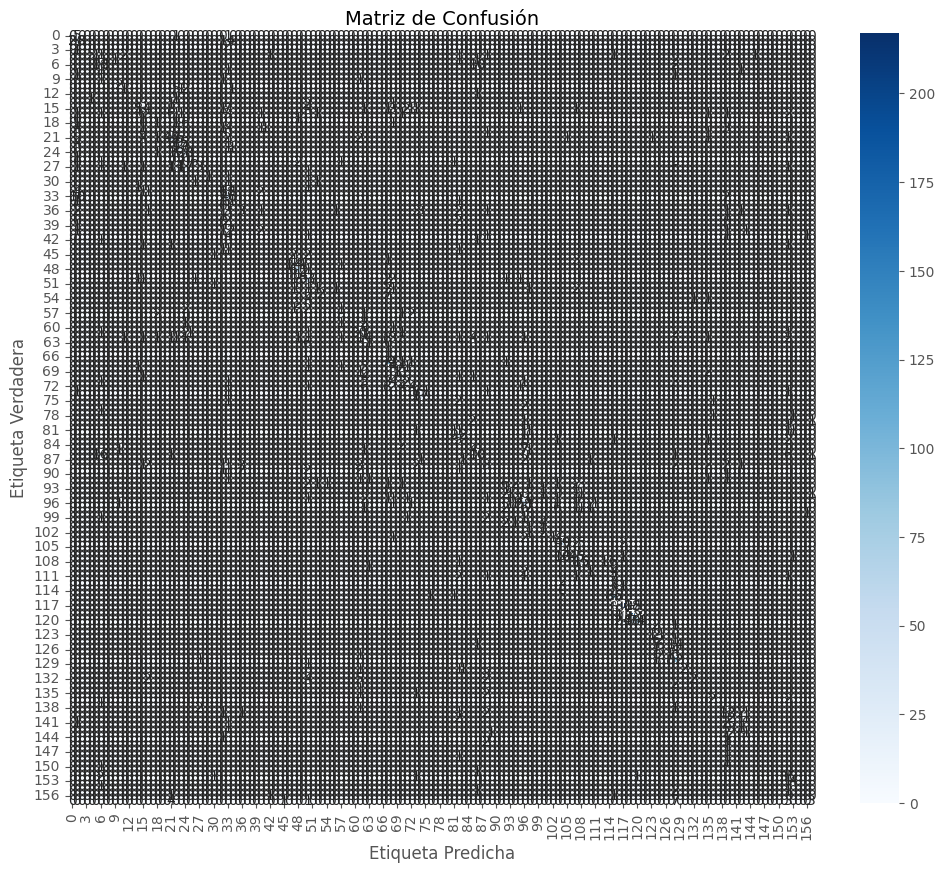

ROC AUC (macro-average): 0.9683
ROC AUC (weighted-average): 0.9810
ROC AUC (micro-average): 0.9879


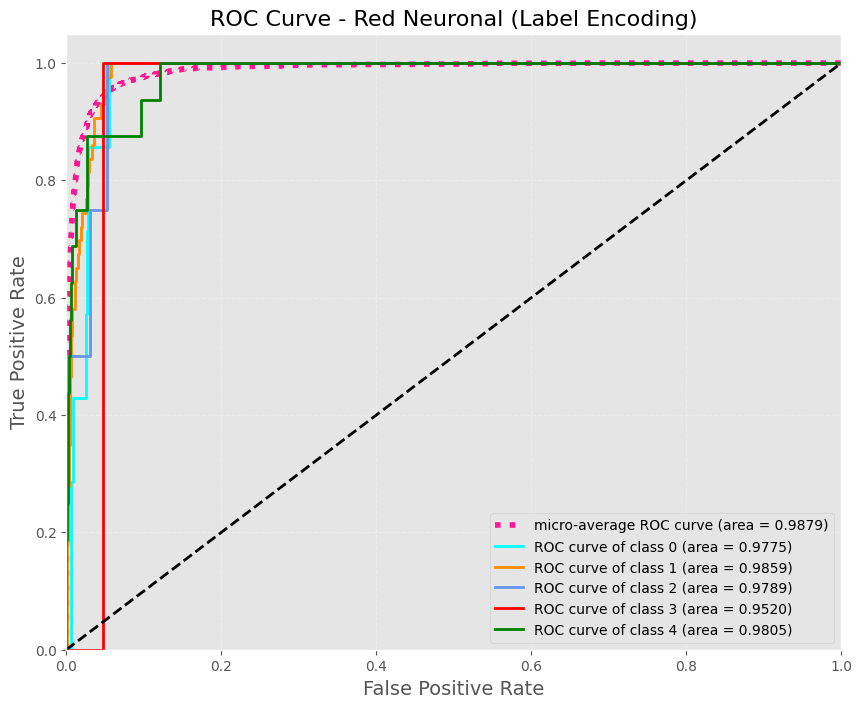


AUC micro-average: 0.9879

Realizando validación cruzada 5-fold...


Resultados de validación cruzada 5-fold:
Accuracy por fold: [0.4779, 0.4884, 0.4877, 0.4917, 0.4864]
Accuracy media: 0.4864
Desviación estándar: 0.0046

Accuracy final de entrenamiento: 0.5315
Accuracy final de validación: 0.5435
Brecha entre entrenamiento y validación: -0.0121

Modelo guardado como 'neural_network_label_model.h5'

Realizando análisis de errores...

Errores más comunes (Verdadero -> Predicho):
Clase verdadera 120 predicha como 119: 50 veces
Clase verdadera 120 predicha como 117: 24 veces
Clase verdadera 32 predicha como 33: 18 veces
Clase verdadera 117 predicha como 119: 18 veces
Clase verdadera 27 predicha como 24: 17 veces
Clase verdadera 86 predicha como 6: 16 veces
Clase verdadera 22 predicha como 23: 15 veces
Clase verdadera 125 predicha como 128: 14 veces
Clase verdadera 1 predicha como 33: 14 veces
Clase verdadera 40 predicha como 33: 12 veces


In [96]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

try:
    # Intentar cargar el archivo label_encoded_data.csv
    df = pd.read_csv("label_encoded_data.csv", sep=',')
    print("Dataset label_encoded_data.csv cargado exitosamente.")
except FileNotFoundError:
    print("Ningún archivo de datos encontrado. Verificar las rutas.")
    exit()

# Mostrar información básica del dataset
print(f"Dimensiones del dataset: {df.shape}")
print("Primeras 5 filas:")
print(df.head())

# Verificar si la columna 'GRD' existe en el dataset
if 'GRD' not in df.columns:
    print("Error: La columna 'GRD' no existe en el dataset.")
    # Buscar posibles columnas de target
    possible_targets = [col for col in df.columns if 'GRD' in col or 'target' in col.lower() or 'class' in col.lower()]
    if possible_targets:
        print(f"Posibles columnas target encontradas: {possible_targets}")
        target_col = possible_targets[0]
        print(f"Usando '{target_col}' como columna target.")
    else:
        print("No se encontraron posibles columnas target. Asumiendo que la última columna es el target.")
        target_col = df.columns[-1]
        print(f"Usando '{target_col}' como columna target.")
else:
    target_col = 'GRD'

# Separar features y target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Mostrar información sobre las clases
class_counts = y.value_counts()
print("\nDistribución de clases (GRD):")
print(class_counts)
n_classes = len(class_counts)
print(f"Número de clases: {n_classes}")

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Label encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convertir a categorical para el entrenamiento
y_train_categorical = to_categorical(y_train_encoded)
y_test_categorical = to_categorical(y_test_encoded)

# Verificar las dimensiones después del preprocesamiento
print(f"\nDimensiones después del preprocesamiento:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"y_train_categorical: {y_train_categorical.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_test_categorical: {y_test_categorical.shape}")

# Definir y compilar el modelo de red neuronal
print("\nCreando modelo de red neuronal...")
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

# Compilar el modelo
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
model.summary()

# Configurar early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Entrenar el modelo
print("\nEntrenando modelo...")
history = model.fit(
    X_train_scaled, y_train_categorical,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Visualizar el progreso del entrenamiento
plt.figure(figsize=(12, 5))

# Gráfico de precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico de pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Pérdida', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Evaluar el modelo en el conjunto de prueba
print("\nEvaluando modelo en el conjunto de prueba...")
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_test_classes_int = y_test_encoded

# Calcular métricas de rendimiento
accuracy = accuracy_score(y_test_classes_int, y_pred_classes)
precision = precision_score(y_test_classes_int, y_pred_classes, average='weighted', zero_division=0)
recall = recall_score(y_test_classes_int, y_pred_classes, average='weighted', zero_division=0)

print("Resultados en el conjunto de prueba:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Informe de clasificación detallado
print("\nInforme de clasificación detallado:")
print(classification_report(y_test_classes_int, y_pred_classes))

# Visualizar matriz de confusión
print("\nGenerando matriz de confusión...")
cm = confusion_matrix(y_test_classes_int, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión', fontsize=14)

plt.ylabel('Etiqueta Verdadera', fontsize=12)
plt.xlabel('Etiqueta Predicha', fontsize=12)
plt.show()

# Calcular ROC AUC para multiclase
from sklearn.preprocessing import label_binarize

# Binarizar las etiquetas de prueba
y_test_bin = label_binarize(y_test_classes_int, classes=np.arange(n_classes))

# Calcular ROC AUC para cada clase y promediar
roc_auc_macro = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr', average='weighted')
roc_auc_micro = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr', average='micro')

print(f"ROC AUC (macro-average): {roc_auc_macro:.4f}")
print(f"ROC AUC (weighted-average): {roc_auc_weighted:.4f}")
print(f"ROC AUC (micro-average): {roc_auc_micro:.4f}")

# Graficar ROC curves para Label Encoding
plt.figure(figsize=(10, 8))

# Calcular fpr y tpr para cada clase
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular fpr y tpr para el promedio micro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Graficar la curva ROC micro-promedio
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average ROC curve (area = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle=':', linewidth=4)

# Graficar ROC curve para algunas clases
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red', 'green']
for i, color in zip(range(min(5, n_classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve - Red Neuronal (Label Encoding)', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Imprimir AUC promedio
print(f"\nAUC micro-average: {roc_auc['micro']:.4f}")

# Validación cruzada
print("\nRealizando validación cruzada 5-fold...")
# Para validación cruzada, necesitamos una función que entrene y evalúe el modelo
def build_and_evaluate_model(X_train, y_train):
    # Crear y compilar modelo
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Entrenar modelo con early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.3,
        callbacks=[early_stopping],
        verbose=0
    )

    return model

# Realizar validación cruzada manualmente
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in cv.split(X_train_scaled, y_train_encoded):
    # Obtener datos de entrenamiento y validación para esta iteración
    X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_cv_train = y_train_categorical[train_idx]
    y_cv_val = y_train_categorical[val_idx]

    # Entrenar modelo
    cv_model = build_and_evaluate_model(X_cv_train, y_cv_train)

    # Evaluar modelo
    _, accuracy = cv_model.evaluate(X_cv_val, y_cv_val, verbose=0)
    cv_scores.append(accuracy)

# Mostrar resultados de validación cruzada
print(f"Resultados de validación cruzada 5-fold:")
print(f"Accuracy por fold: {[round(score, 4) for score in cv_scores]}")
print(f"Accuracy media: {np.mean(cv_scores):.4f}")
print(f"Desviación estándar: {np.std(cv_scores):.4f}")

# Imprimir los valores finales de accuracy y loss
print(f"\nAccuracy final de entrenamiento: {history.history['accuracy'][-1]:.4f}")
print(f"Accuracy final de validación: {history.history['val_accuracy'][-1]:.4f}")
print(f"Brecha entre entrenamiento y validación: {history.history['accuracy'][-1] - history.history['val_accuracy'][-1]:.4f}")

# Guardar el modelo
model.save("neural_network_label_model.h5")
print("\nModelo guardado como 'neural_network_label_model.h5'")

# Análisis de errores
print("\nRealizando análisis de errores...")
error_indices = np.where(y_pred_classes != y_test_classes_int)[0]
error_counts = {}

for idx in error_indices:
    true_class = y_test_classes_int[idx]
    pred_class = y_pred_classes[idx]
    error_pair = (true_class, pred_class)

    if error_pair in error_counts:
        error_counts[error_pair] += 1
    else:
        error_counts[error_pair] = 1

# Mostrar los errores más comunes
print("\nErrores más comunes (Verdadero -> Predicho):")
sorted_errors = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)
for (true_class, pred_class), count in sorted_errors[:10]:
    print(f"Clase verdadera {true_class} predicha como {pred_class}: {count} veces")
